# 페니실린 농도 예측 모델 — 최종 모델 선정 과정

본 노트북은 담당 업무인 **페니실린 농도 예측 ML 모델**의 최종 모델(피처셋)이 확정되기까지의
전체 과정을 실제 데이터(`merged_data.csv`)로 재현 가능하게 정리한 기록입니다.

**목차**
1. 기본 변수 선정 (base21)
2. 파생 변수 선정 (팀원 제공 6종)
3. 파생 변수별 결과값 (단일변수 추가 테스트)
4. GB_score_cum_v2 — 골든밴드팀 최종 방법론 반영
5. pH_excursion_ratio 제외 → 최종 24개 채택
6. 최종 성능 비교 (호라이즌별)
7. 최종 검정 과정 (하이퍼파라미터·다중공선성·폴드안정성·Fault재검증·배치별검증)
8. 결론 — 최종 모델 스펙 요약

(참고: 1차 최종안(25개) 선정 과정에서 파생변수 순차 조합 테스트, Ablation Study, 문제 배치 92·96·98 원인 진단을 거쳤으나, 최종 채택안(24개)과 무관한 중간 탐색 과정이라 본 문서에서는 생략했습니다. 결과에 필요한 정의만 4절 도입부에 남겨두었습니다.)

모델은 전 과정에서 **LightGBM(LGBMRegressor, 라이브러리 기본값, random_state=42)**,
검증은 **GroupKFold(5), groups=Batch_ID**로 고정합니다.


## 0. 데이터 로드 및 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import wilcoxon
from scipy.interpolate import PchipInterpolator
from sklearn.inspection import partial_dependence
import lightgbm as lgb

pd.set_option('display.max_columns', None)

BLUE, ORANGE, AQUA, VIOLET = '#2a78d6', '#eb6834', '#1baf7a', '#4a3aa7'

df = pd.read_csv('merged_data.csv').sort_values(['Batch_ID', 'Time (h)']).reset_index(drop=True)
target_col = 'Penicillin concentration(P:g/L)'
TIME_COL = 'Time (h)'
BATCH_COL = 'Batch_ID'
df['_bid'] = df[BATCH_COL]  # pandas 3.0 groupby(...).apply() 그룹핑 컬럼 제외 이슈 우회용 그림자 컬럼
STEP = 0.2
fault_ids = list(range(91, 101))

print('데이터 shape:', df.shape)
print('배치 수:', df[BATCH_COL].nunique(), ' (1-90 정상 / 91-100 Fault)')


데이터 shape: (113935, 40)
배치 수: 100  (1-90 정상 / 91-100 Fault)


## 1. 기본 변수 선정 (base21)

원본 데이터 34개 변수 중 팀 기존 베이스라인은 17개만 사용했는데, 그 선정 기준이 불명확했습니다.
검토 결과 4개(`Fh`, `Fw`, `Fremoved`, `Fpaa`)는 결측치·상수값 등 기술적 문제가 없었음에도
근거 없이 빠져 있어 재검토 후 정식 편입했습니다. 반대로 `Oil flow`는 발효 단계를 그대로 인코딩하는
'단계 프록시' 변수, `Vessel Weight`는 이미 포함된 `Vessel Volume`과 중복 정보(질량 vs 부피)라 계속 제외합니다.

In [2]:
BASE17 = ['Aeration rate(Fg:L/h)', 'Sugar feed rate(Fs:L/h)', 'Acid flow rate(Fa:L/h)',
          'Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)',
          'Air head pressure(pressure:bar)', 'Substrate concentration(S:g/L)',
          'Dissolved oxygen concentration(DO2:mg/L)', 'pH(pH:pH)', 'Temperature(T:K)',
          'Generated heat(Q:kJ)', 'carbon dioxide percent in off-gas(CO2outgas:%)',
          'Oxygen in percent in off-gas(O2:O2  (%))', 'Oxygen Uptake Rate(OUR:(g min^{-1}))',
          'Carbon evolution rate(CER:g/h)', 'Vessel Volume(V:L)', 'Time (h)']
EXTRA4 = ['Heating water flow rate(Fh:L/h)', 'Water for injection/dilution(Fw:L/h)',
          'Dumped broth flow(Fremoved:L/h)', 'PAA flow(Fpaa:PAA flow (L/h))']
BASE21 = BASE17 + EXTRA4
print(f'BASE21 = 원본 17개 + 재편입 4개 = {len(BASE21)}개')

# 재편입 4개: 결측/상수 문제 없음 확인
for c in EXTRA4:
    print(f'  {c[:40]:42s} 결측 {df[c].isna().mean()*100:.1f}%  고유값 {df[c].nunique()}')

# 제외 변수 근거: Oil flow는 시간과 강하게 연동(단계 프록시), Vessel Weight는 Volume과 중복
print()
print('Oil flow - Time(h) 상관계수     :', round(df['Oil flow(Foil:L/hr)'].corr(df[TIME_COL]), 3))
print('Vessel Weight - Vessel Volume 상관계수:', round(df['Vessel Weight(Wt:Kg)'].corr(df['Vessel Volume(V:L)']), 3))


BASE21 = 원본 17개 + 재편입 4개 = 21개
  Heating water flow rate(Fh:L/h)            결측 0.0%  고유값 54534
  Water for injection/dilution(Fw:L/h)       결측 0.0%  고유값 6
  Dumped broth flow(Fremoved:L/h)            결측 0.0%  고유값 2
  PAA flow(Fpaa:PAA flow (L/h))              결측 0.0%  고유값 22931

Oil flow - Time(h) 상관계수     : -0.739
Vessel Weight - Vessel Volume 상관계수: 0.995


## 2. 파생 변수 선정 (팀원 제공 6종)

팀원분이 통계분석(다변량 회귀·골든배치 게이트·넬슨룰 등) 근거로 제안한 6개 파생변수입니다.

| 변수 | 의미 |
|---|---|
| `Fa_cum` | 산(Acid) 누적 투입량 (사다리꼴 적분) |
| `Fb_cum` | 염기(Base) 누적 투입량 |
| `S_slope20h` | 최근 20시간 기질농도 이동창 회귀 기울기 |
| `OUR_slope20h` | 최근 20시간 산소소모율(OUR) 이동창 회귀 기울기 |
| `GB_score_cum` | 골든밴드 대비 SMAPE 이탈점수의 누적합 (7변수, 전략별 밴드) |
| `pH_excursion_ratio` | pH가 정상범위(3×IQR)를 1시간 이상 지속 이탈한 누적 비율 |


In [3]:
COLMAP = {
    '산투입유량(L/h)': 'Acid flow rate(Fa:L/h)',
    '염기투입유량(L/h)': 'Base flow rate(Fb:L/h)',
    '기질농도_S': 'Substrate concentration(S:g/L)',
    '산소소모율(g/min)': 'Oxygen Uptake Rate(OUR:(g min^{-1}))',
    '수소이온농도(pH)': 'pH(pH:pH)',
    '발효온도(K)': 'Temperature(T:K)',
    '냉난방수유량(L/h)': 'Heating/cooling water flow rate(Fc:L/h)',
    '페니실린농도(g/L)': target_col,
    '용존산소농도(mg/L)': 'Dissolved oxygen concentration(DO2:mg/L)',
}
print('컬럼명 매핑(팀원 한글 표기 -> merged_data.csv 실제 컬럼) 완료:', len(COLMAP), '개')


컬럼명 매핑(팀원 한글 표기 -> merged_data.csv 실제 컬럼) 완료: 9 개


In [4]:
# 2.1 Fa_cum, Fb_cum -- 누적투입량(사다리꼴 적분)
def add_cumulative_input(df, flow_col, cum_col, time_col=TIME_COL, batch_col=BATCH_COL):
    def _cumtrapz(g):
        g = g.sort_values(time_col)
        t, x = g[time_col].to_numpy(), g[flow_col].to_numpy()
        dt = np.diff(t, prepend=t[0])
        avg = np.concatenate([[x[0]], (x[1:] + x[:-1]) / 2])
        return pd.Series(np.cumsum(avg * dt), index=g.index)
    result = df.groupby(batch_col, group_keys=False)[[time_col, flow_col]].apply(_cumtrapz)
    df[cum_col] = result
    return df

df = add_cumulative_input(df, COLMAP['산투입유량(L/h)'], 'Fa_cum')
df = add_cumulative_input(df, COLMAP['염기투입유량(L/h)'], 'Fb_cum')
print('Fa_cum, Fb_cum 생성 완료')
print(df[['Batch_ID', 'Time (h)', 'Fa_cum', 'Fb_cum']].tail(3))


Fa_cum, Fb_cum 생성 완료
        Batch_ID  Time (h)     Fa_cum        Fb_cum
113932       100     229.6  54.391716  11364.387276
113933       100     229.8  54.391716  11365.751306
113934       100     230.0  54.391716  11367.109796


In [5]:
# 2.2 S_slope20h, OUR_slope20h -- 20시간 이동창 회귀 기울기 (closed-form OLS)
def rolling_slope_fast(t, x, window_points, min_periods=2):
    n = t.rolling(window_points, min_periods=min_periods).count()
    sum_t = t.rolling(window_points, min_periods=min_periods).sum()
    sum_x = x.rolling(window_points, min_periods=min_periods).sum()
    sum_tx = (t * x).rolling(window_points, min_periods=min_periods).sum()
    sum_tt = (t * t).rolling(window_points, min_periods=min_periods).sum()
    denom = n * sum_tt - sum_t ** 2
    return (n * sum_tx - sum_t * sum_x) / denom.replace(0, np.nan)

WINDOW_POINTS = int(round(20 / STEP))

def add_rolling_slope(df, col, out_col, time_col=TIME_COL, batch_col=BATCH_COL):
    def _apply(g):
        g = g.sort_values(time_col)
        return rolling_slope_fast(g[time_col], g[col], WINDOW_POINTS)
    result = df.groupby(batch_col, group_keys=False)[[time_col, col]].apply(_apply)
    df[out_col] = result
    return df

df = add_rolling_slope(df, COLMAP['기질농도_S'], 'S_slope20h')
df = add_rolling_slope(df, COLMAP['산소소모율(g/min)'], 'OUR_slope20h')
df[['S_slope20h', 'OUR_slope20h']] = df[['S_slope20h', 'OUR_slope20h']].fillna(0)
print('S_slope20h, OUR_slope20h 생성 완료')


S_slope20h, OUR_slope20h 생성 완료


In [6]:
# 2.3 pH_excursion_ratio -- pH 3xIQR 지속이탈(1h+) 누적비율 (정상90배치 기준 IQR)
normal_mask_all = ~df[BATCH_COL].isin(fault_ids)
Q1, Q3 = df.loc[normal_mask_all, COLMAP['수소이온농도(pH)']].quantile([0.25, 0.75])
IQR = Q3 - Q1
PH_LOWER, PH_UPPER = Q1 - 3 * IQR, Q3 + 3 * IQR
MIN_PERSIST_POINTS = int(round(1.0 / STEP))

def add_pH_excursion_ratio(df, col, time_col=TIME_COL, batch_col=BATCH_COL):
    def _apply(g):
        g = g.sort_values(time_col)
        out_of_band = (g[col] < PH_LOWER) | (g[col] > PH_UPPER)
        run_id = (out_of_band != out_of_band.shift(fill_value=False)).cumsum()
        run_len_so_far = out_of_band.groupby(run_id).cumcount() + 1
        persistent_now = out_of_band & (run_len_so_far >= MIN_PERSIST_POINTS)
        ratio = persistent_now.astype(int).cumsum() / np.arange(1, len(g) + 1)
        return pd.Series(ratio.to_numpy(), index=g.index)
    result = df.groupby(batch_col, group_keys=False)[[time_col, col]].apply(_apply)
    df['pH_excursion_ratio'] = result
    return df

df = add_pH_excursion_ratio(df, COLMAP['수소이온농도(pH)'])
print(f'pH_excursion_ratio 생성 완료 (IQR band: [{PH_LOWER:.3f}, {PH_UPPER:.3f}])')


pH_excursion_ratio 생성 완료 (IQR band: [6.448, 6.554])


In [7]:
# 2.4 GB_score_cum (v1) -- 골든밴드(SMAPE) 기반 이탈점수 누적합
#     전략 매핑: Batch_ID 1-30=RC, 31-60=OC, 61-90=APC, 91-100=Fault(전략라벨 없음 -> APC로 가정, 4절에서 실제라벨로 교체)
GOLDEN_BATCHES = {'RC': [8, 12, 14, 16, 17, 26], 'OC': [35, 48, 57], 'APC': [62, 65, 68, 79, 82, 85]}

def strategy_of(b):
    if 1 <= b <= 30: return 'RC'
    if 31 <= b <= 60: return 'OC'
    if 61 <= b <= 90: return 'APC'
    return 'APC'  # Fault(91-100) 가정 -- 4절에서 실제 라벨로 교체 후 재검증

df['strategy'] = df[BATCH_COL].apply(strategy_of)
GB_FEATURES = [COLMAP[k] for k in ['페니실린농도(g/L)', '용존산소농도(mg/L)', '수소이온농도(pH)', '발효온도(K)', '산소소모율(g/min)']] + \
              ['Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)']

strategy_mean_duration = df[df[BATCH_COL] <= 90].groupby('strategy').apply(
    lambda g: g.groupby(BATCH_COL)[TIME_COL].max().mean()).to_dict()
print('전략별 평균 배치시간(h):', {k: round(v, 1) for k, v in strategy_mean_duration.items()})

N_BINS = 50
def build_golden_band(df_all, batch_list, strategy, cols, n_bins=N_BINS):
    sub = df_all[df_all[BATCH_COL].isin(batch_list)].copy()
    dur = strategy_mean_duration[strategy]
    sub['progress'] = (sub[TIME_COL] / dur).clip(0, 1)
    sub['bin'] = (sub['progress'] * n_bins).round().astype(int).clip(0, n_bins)
    band = sub.groupby('bin')[cols].mean().reset_index()
    band['progress'] = band['bin'] / n_bins
    return band.rename(columns={c: f'{c}_mean' for c in cols})[['progress'] + [f'{c}_mean' for c in cols]]

golden_bands_full = {s: build_golden_band(df, b, s, GB_FEATURES) for s, b in GOLDEN_BATCHES.items()}
golden_bands_loo = {s: {b: build_golden_band(df, [x for x in bts if x != b], s, GB_FEATURES) for b in bts}
                    for s, bts in GOLDEN_BATCHES.items()}

def get_band_for_batch(b, strat):
    if strat in GOLDEN_BATCHES and b in GOLDEN_BATCHES[strat]:
        return golden_bands_loo[strat][b]
    return golden_bands_full.get(strat, golden_bands_full['APC'])

def smape(actual, forecast):
    denom = np.abs(actual) + np.abs(forecast)
    denom = np.where(denom == 0, 1e-9, denom)
    return np.abs(actual - forecast) / denom

def add_gb_score_cum(df, cols=GB_FEATURES):
    def _apply(g):
        g = g.sort_values(TIME_COL)
        strat = g['strategy'].iloc[0]
        b = g['_bid'].iloc[0]
        band = get_band_for_batch(b, strat)
        dur = strategy_mean_duration.get(strat, strategy_mean_duration['APC'])
        progress = (g[TIME_COL] / dur).clip(0, 1)
        gm = {c: np.interp(progress, band['progress'], band[f'{c}_mean']) for c in cols}
        per_feat = np.stack([smape(g[c].to_numpy(), gm[c]) for c in cols], axis=0)
        gb_score = per_feat.mean(axis=0)
        return pd.DataFrame({'GB_score': gb_score, 'GB_score_cum': np.cumsum(gb_score)}, index=g.index)
    result = df.groupby(BATCH_COL, group_keys=False)[['_bid', 'strategy', TIME_COL] + cols].apply(_apply)
    df[['GB_score', 'GB_score_cum']] = result
    return df

df = add_gb_score_cum(df)
print('GB_score_cum(v1) 생성 완료')
NEW_FEATS_ALL = ['Fa_cum', 'Fb_cum', 'S_slope20h', 'OUR_slope20h', 'GB_score_cum', 'pH_excursion_ratio']


전략별 평균 배치시간(h): {'APC': 224.7, 'OC': 229.2, 'RC': 228.8}
GB_score_cum(v1) 생성 완료


## 3. 파생 변수별 결과값 (단일변수 추가 테스트)

각 파생변수를 base21에 **하나씩만** 추가했을 때 전체 R²/MAE가 어떻게 바뀌는지 확인합니다. 이 결과가 이후 '어떤 변수를 채택할지'를 결정하는 핵심 근거가 됩니다.

In [8]:
H = 12
steps = round(H / STEP)
tgt_col = f'target_{H}h'
df[tgt_col] = df.groupby(BATCH_COL)[target_col].shift(-steps)
data = df.dropna(subset=[tgt_col]).copy()
data_orig_idx = data.index.to_numpy()  # df 원본 인덱스 보존 (이후 df에서 새 파생변수를 역참조할 때 사용)
data = data.reset_index(drop=True)
y = data[tgt_col]
groups = data[BATCH_COL]

all_cols_seen = sorted(set(BASE21 + NEW_FEATS_ALL))
safe = {c: f'f{i}' for i, c in enumerate(all_cols_seen)}

def run_gkf(X, y, groups, n_splits=5, params=None):
    oof = np.zeros(len(X))
    p = dict(random_state=42, n_jobs=2, verbosity=-1)
    if params: p.update(params)
    for tr, te in GroupKFold(n_splits).split(X, groups=groups):
        m = lgb.LGBMRegressor(**p)
        m.fit(X.iloc[tr], y.iloc[tr])
        oof[te] = m.predict(X.iloc[te])
    return oof

def report(y, oof):
    return {'R2': round(r2_score(y, oof), 4), 'MAE': round(mean_absolute_error(y, oof), 4),
            'RMSE': round(np.sqrt(mean_squared_error(y, oof)), 4)}

oof_base21 = run_gkf(data[BASE21].rename(columns=safe), y, groups)
base_report = report(y, oof_base21)
print(f'[base21] {base_report}')

single_feat_oof = {}  # 이하 사전 준비 셀에서 재사용
single_rows = [{'구성': 'base21(기존)', **base_report, 'deltaR2': 0.0}]
for feat in NEW_FEATS_ALL:
    cols = BASE21 + [feat]
    oof = run_gkf(data[cols].rename(columns=safe), y, groups)
    single_feat_oof[feat] = oof
    r = report(y, oof)
    single_rows.append({'구성': f'+{feat}', **r, 'deltaR2': round(r['R2'] - base_report['R2'], 4)})
    print(f'[+{feat}] {r}  (deltaR2={r["R2"]-base_report["R2"]:+.4f})')

single_df = pd.DataFrame(single_rows)
print()
print(single_df.to_string(index=False))


[base21] {'R2': 0.9738, 'MAE': 1.0604, 'RMSE': np.float64(1.5529)}
[+Fa_cum] {'R2': 0.973, 'MAE': 1.0821, 'RMSE': np.float64(1.5763)}  (deltaR2=-0.0008)
[+Fb_cum] {'R2': 0.9714, 'MAE': 1.102, 'RMSE': np.float64(1.6229)}  (deltaR2=-0.0024)
[+S_slope20h] {'R2': 0.9737, 'MAE': 1.0572, 'RMSE': np.float64(1.5572)}  (deltaR2=-0.0001)
[+OUR_slope20h] {'R2': 0.9739, 'MAE': 1.0567, 'RMSE': np.float64(1.5515)}  (deltaR2=+0.0001)
[+GB_score_cum] {'R2': 0.9755, 'MAE': 1.0288, 'RMSE': np.float64(1.5019)}  (deltaR2=+0.0017)
[+pH_excursion_ratio] {'R2': 0.9744, 'MAE': 1.0407, 'RMSE': np.float64(1.5344)}  (deltaR2=+0.0006)

                 구성     R2    MAE   RMSE  deltaR2
         base21(기존) 0.9738 1.0604 1.5529   0.0000
            +Fa_cum 0.9730 1.0821 1.5763  -0.0008
            +Fb_cum 0.9714 1.1020 1.6229  -0.0024
        +S_slope20h 0.9737 1.0572 1.5572  -0.0001
      +OUR_slope20h 0.9739 1.0567 1.5515   0.0001
      +GB_score_cum 0.9755 1.0288 1.5019   0.0017
+pH_excursion_ratio 0.9744 1.0407 


핵심 발견: Fa_cum/Fb_cum은 Feature Importance 순위는 높지만(Time(h)과 정보 중복, 둘 다 누적/단조증가형)
단독 추가 시 오히려 R²를 떨어뜨림. GB_score_cum/pH_excursion_ratio가 실질적 기여 변수.


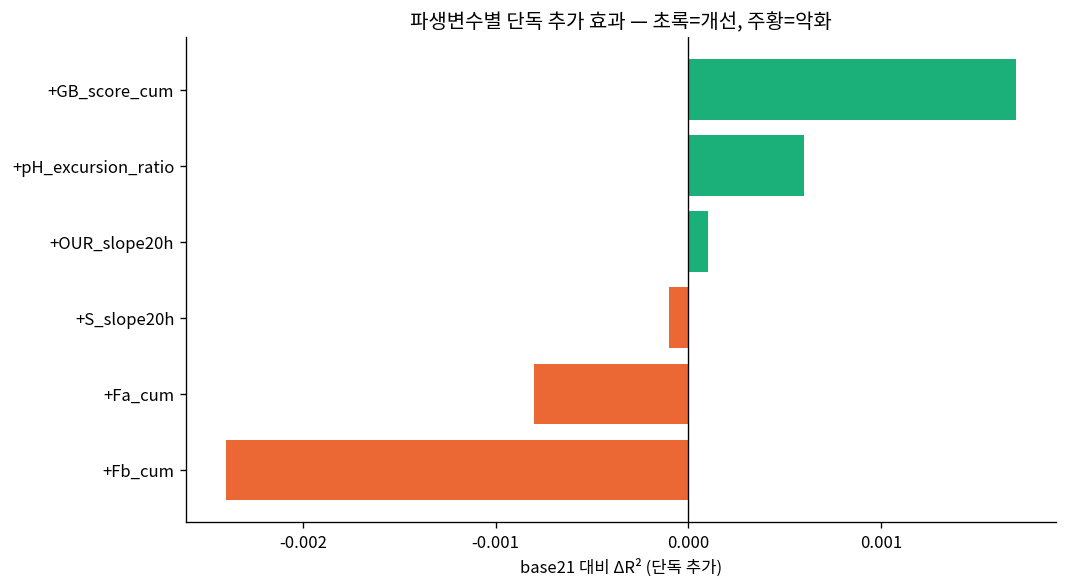

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_d = single_df.iloc[1:].sort_values('deltaR2')
colors = [ORANGE if v < 0 else AQUA for v in plot_d['deltaR2']]
ax.barh(plot_d['구성'], plot_d['deltaR2'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('base21 대비 ΔR² (단독 추가)')
ax.set_title('파생변수별 단독 추가 효과 — 초록=개선, 주황=악화')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\n핵심 발견: Fa_cum/Fb_cum은 Feature Importance 순위는 높지만(Time(h)과 정보 중복, 둘 다 누적/단조증가형)')
print('단독 추가 시 오히려 R²를 떨어뜨림. GB_score_cum/pH_excursion_ratio가 실질적 기여 변수.')


In [10]:
# 이후 절(GB_score_cum_v2 비교, 최종 검정)에서 재사용하는 정의 모음
FINAL_V1 = BASE21 + ['GB_score_cum', 'pH_excursion_ratio', 'OUR_slope20h', 'S_slope20h']  # 1차 최종안(25개, 참고용)
TARGET_BATCHES = [92, 96, 98]  # 1차 최종안에서 유독 악화됐던 문제 배치(원인: pH_excursion_ratio, GB_score_cum)

def batch_mae(oof, b):
    mask = (data[BATCH_COL] == b).to_numpy()
    return mean_absolute_error(y[mask], oof[mask])

normal_mask = ~data[BATCH_COL].isin(fault_ids)
normal_data = data[normal_mask].reset_index(drop=True)
fault_data = data[~normal_mask].reset_index(drop=True)

actual_fault_window = {}
for b in fault_ids:
    sub = df[df[BATCH_COL] == b]
    fr = sub[sub['Fault reference(Fault_ref:Fault ref)'] == 1]
    actual_fault_window[b] = (fr[TIME_COL].min(), fr[TIME_COL].max())

def sustained_onset(sub, score_col, thresh, window=5, need=5):
    sub = sub.sort_values(TIME_COL).reset_index(drop=True)
    flag = (sub[score_col] > thresh).astype(int)
    roll = flag.rolling(window).sum()
    idx = roll[roll >= need].index
    if len(idx) == 0: return np.nan
    return sub.loc[idx[0] - window + 1, TIME_COL]

def fault_eval(cols, label):
    Xn = normal_data[cols].rename(columns=safe); yn = normal_data[tgt_col]; gn = normal_data[BATCH_COL]
    oof = run_gkf(Xn, yn, gn)
    normal_mae, normal_r2 = mean_absolute_error(yn, oof), r2_score(yn, oof)
    final = lgb.LGBMRegressor(random_state=42, n_jobs=2, verbosity=-1)
    final.fit(Xn, yn)
    fpred = final.predict(fault_data[cols].rename(columns=safe))
    fault_mae = mean_absolute_error(fault_data[tgt_col], fpred)
    nd = normal_data.copy(); nd['abs_err'] = np.abs(oof - yn.to_numpy())
    fd = fault_data.copy(); fd['abs_err'] = np.abs(fpred - fault_data[tgt_col].to_numpy())
    thresh = nd['abs_err'].quantile(0.95)
    delays, detected = [], []
    for b in fault_ids:
        onset = sustained_onset(fd[fd[BATCH_COL] == b], 'abs_err', thresh)
        start, _ = actual_fault_window[b]
        if not np.isnan(onset):
            delays.append(onset - start); detected.append(b)
    print(f'[{label}] 정상R2={normal_r2:.4f} 정상MAE={normal_mae:.4f} FaultMAE={fault_mae:.4f} '
          f'p95임계값={thresh:.4f} 탐지={len(delays)}/10 {sorted(detected)}')
    return dict(normal_mae=normal_mae, fault_mae=fault_mae, thresh=thresh, detected=detected)

data_bl = data.copy()
data_bl['pred_base21'] = oof_base21
print('사전 준비 완료 (이후 절에서 재사용할 정의)')


사전 준비 완료 (이후 절에서 재사용할 정의)


## 4. GB_score_cum_v2 — 골든밴드팀 최종 방법론 반영

골든밴드팀이 확정한 최종 파이프라인(11개 CPP 변수, PCHIP/계단형 보간, Fault 배치 실제 전략라벨)을 그대로 반영하되, 매 시점 갱신되는 '누적' 형태로 재계산합니다. (참고: 1차 최종안(25개, `GB_score_cum` v1 + `pH_excursion_ratio` 포함)에서 배치 92·96·98이 유독 악화되는 문제가 발견되어, `pH_excursion_ratio`(92·98 원인)와 `GB_score_cum`(96 원인)이 각각 독립적 원인임을 진단했고, 그 결과로 아래 v2 도입을 결정했습니다.)

**[수정 반영] strategy_mean_duration 기준 통일**: progress(진행률) 계산의 분모인 전략별 평균 운전시간을 처음에는 정상90 배치 전체로 계산했으나, 대시보드(이탈진단/Replay)팀에서 Test 정상19개를 최종평가용으로 별도 분리해 둔 사실을 확인해주셨습니다. 정상90 전체를 쓰면 Test 배치의 실제 종료시간이 feature 계산 기준에 섞여 들어가는 형태가 되므로, 대시보드팀과 동일하게 **Train 정상71개 기준값(RC=232.125h/OC=226.739h/APC=225.458h)**으로 통일했습니다. 교체 후 재검증한 결과(①12h R²/MAE ②GB_score_cum_v2-Time 상관 ③배치별 개선 유지 ④Fault 성능) 기존 대비 유의미한 성능 차이는 없었습니다.

In [11]:
FAULT_STRATEGY_REAL = {91: 'APC', 92: 'OC', 93: 'OC', 94: 'APC', 95: 'RC',
                        96: 'APC', 97: 'APC', 98: 'APC', 99: 'APC', 100: 'APC'}

def strategy_of_v2(b):
    if 1 <= b <= 30: return 'RC'
    if 31 <= b <= 60: return 'OC'
    if 61 <= b <= 90: return 'APC'
    return FAULT_STRATEGY_REAL[b]

df['strategy_v2'] = df[BATCH_COL].apply(strategy_of_v2)
CPP_11 = ['Penicillin concentration(P:g/L)', 'Dissolved oxygen concentration(DO2:mg/L)', 'pH(pH:pH)',
          'Temperature(T:K)', 'Aeration rate(Fg:L/h)', 'Sugar feed rate(Fs:L/h)', 'Acid flow rate(Fa:L/h)',
          'Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)',
          'PAA flow(Fpaa:PAA flow (L/h))', 'Oxygen Uptake Rate(OUR:(g min^{-1}))']
STEP_VARS = ['Aeration rate(Fg:L/h)', 'Sugar feed rate(Fs:L/h)', 'Acid flow rate(Fa:L/h)', 'PAA flow(Fpaa:PAA flow (L/h))']

# [수정 반영] 정상90 전체 평균이 아닌, 대시보드(이탈진단/Replay)팀이 확정한
# Train 정상71개 기준값을 그대로 사용 (Test 정상19개는 최종평가용으로 분리되어 있어
# 정상90 전체로 계산하면 Test 정보가 feature 생성 기준에 섞여 들어갈 소지가 있음).
# ML과 대시보드가 동일한 값을 쓰도록 통일.
strategy_mean_duration_v2_by_normal90 = df[df[BATCH_COL] <= 90].groupby('strategy_v2').apply(
    lambda g: g.groupby(BATCH_COL)[TIME_COL].max().mean()).to_dict()
strategy_mean_duration_v2 = {'RC': 232.125, 'OC': 226.739, 'APC': 225.458}
print('전략별 평균 배치시간(h) [수정전, 정상90 전체]:',
      {k: round(v, 3) for k, v in strategy_mean_duration_v2_by_normal90.items()})
print('전략별 평균 배치시간(h) [최종 채택, Train 정상71 - 대시보드팀 확정값]:', strategy_mean_duration_v2)
PROG_GRID = np.linspace(0, 1, 501)

def interp_by_type(t_known, y_known, query, feat):
    if feat in STEP_VARS:
        idx = np.searchsorted(t_known, query, side='right') - 1
        idx = np.clip(idx, 0, len(t_known) - 1)
        return y_known[idx]
    x_u, keep = np.unique(t_known, return_index=True)
    y_u = y_known[keep]
    if len(x_u) < 2:
        return np.full_like(query, y_u[0] if len(y_u) else np.nan, dtype=float)
    f = PchipInterpolator(x_u, y_u, extrapolate=False)
    r = f(query)
    r = np.where(query < x_u[0], y_u[0], r)
    r = np.where(query > x_u[-1], y_u[-1], r)
    return r

def build_band_v2(batch_list, strategy):
    dur = strategy_mean_duration_v2[strategy]
    curves = {feat: [] for feat in CPP_11}
    for b in batch_list:
        sub = df[df[BATCH_COL] == b].sort_values(TIME_COL)
        prog = (sub[TIME_COL] / dur).clip(upper=1.0).to_numpy()
        for feat in CPP_11:
            curves[feat].append(interp_by_type(prog, sub[feat].to_numpy(), PROG_GRID, feat))
    return {feat: np.nanmean(np.array(v), axis=0) for feat, v in curves.items()}

full_bands_v2 = {s: build_band_v2(b, s) for s, b in GOLDEN_BATCHES.items()}
loo_bands_v2 = {s: {b: build_band_v2([x for x in bts if x != b], s) for b in bts} for s, bts in GOLDEN_BATCHES.items()}

def get_band_v2(b, s):
    if s in GOLDEN_BATCHES and b in GOLDEN_BATCHES[s]:
        return loo_bands_v2[s][b]
    return full_bands_v2[s]

def compute_gb_v2_for_batch(b):
    strat = strategy_of_v2(b)
    band = get_band_v2(b, strat)
    dur = strategy_mean_duration_v2[strat]
    sub = df[df[BATCH_COL] == b].sort_values(TIME_COL)
    progress = (sub[TIME_COL] / dur).clip(upper=1.0).to_numpy()
    per_feat = [smape(sub[feat].to_numpy(), np.interp(progress, PROG_GRID, band[feat])) for feat in CPP_11]
    gb_score = np.mean(np.stack(per_feat, axis=0), axis=0)
    return pd.Series(np.cumsum(gb_score), index=sub.index)

print('GB_score_cum_v2 계산 중 (11변수, 실제 Fault 전략라벨)...')
gb_v2_series = pd.concat([compute_gb_v2_for_batch(b) for b in sorted(df[BATCH_COL].unique())]).sort_index()
df['GB_score_cum_v2'] = gb_v2_series
# data는 df.dropna(...).reset_index(drop=True)로 만들어져 인덱스가 0..N-1로 재배열되어 있으므로,
# df 원본 인덱스(data_orig_idx)로 역참조해야 행이 올바르게 정렬됨
data['GB_score_cum_v2'] = df.loc[data_orig_idx, 'GB_score_cum_v2'].to_numpy()
print('완료. 예시:')
print(df[[BATCH_COL, TIME_COL, 'GB_score_cum_v2']].tail(3))


전략별 평균 배치시간(h) [수정전, 정상90 전체]: {'APC': 224.667, 'OC': 229.233, 'RC': 228.833}
전략별 평균 배치시간(h) [최종 채택, Train 정상71 - 대시보드팀 확정값]: {'RC': 232.125, 'OC': 226.739, 'APC': 225.458}
GB_score_cum_v2 계산 중 (11변수, 실제 Fault 전략라벨)...
완료. 예시:
        Batch_ID  Time (h)  GB_score_cum_v2
113932       100     229.6       184.705588
113933       100     229.8       184.934093
113934       100     230.0       185.207023


In [12]:
safe['GB_score_cum_v2'] = f'f{len(safe)}'
FINAL_V2_25 = BASE21 + ['GB_score_cum_v2', 'pH_excursion_ratio', 'OUR_slope20h', 'S_slope20h']
FINAL_V2_24 = BASE21 + ['GB_score_cum_v2', 'OUR_slope20h', 'S_slope20h']

gb_configs = {
    'base21': BASE21,
    '1차최종안 25개(GB v1)': FINAL_V1,
    'v2 25개(GB_v2 + pH포함)': FINAL_V2_25,
    'v2 24개(GB_v2, pH제외) *최종*': FINAL_V2_24,
}
gb_rows = []
oof_store = {}
for name, cols in gb_configs.items():
    oof = run_gkf(data[cols].rename(columns=safe), y, groups)
    oof_store[name] = oof
    r = report(y, oof)
    b92, b96, b98 = (batch_mae(oof, b) for b in TARGET_BATCHES)
    gb_rows.append({'구성': name, **r, 'B92': round(b92,3), 'B96': round(b96,3), 'B98': round(b98,3)})
    print(f'[{name}] {r}  B92={b92:.3f} B96={b96:.3f} B98={b98:.3f}')

print()
print(pd.DataFrame(gb_rows).to_string(index=False))


[base21] {'R2': 0.9738, 'MAE': 1.0604, 'RMSE': np.float64(1.5529)}  B92=0.513 B96=0.576 B98=1.003
[1차최종안 25개(GB v1)] {'R2': 0.9763, 'MAE': 0.9946, 'RMSE': np.float64(1.4759)}  B92=1.503 B96=0.663 B98=2.007
[v2 25개(GB_v2 + pH포함)] {'R2': 0.9756, 'MAE': 1.0087, 'RMSE': np.float64(1.4976)}  B92=1.467 B96=0.840 B98=2.331
[v2 24개(GB_v2, pH제외) *최종*] {'R2': 0.976, 'MAE': 1.0122, 'RMSE': np.float64(1.4865)}  B92=0.524 B96=1.013 B98=1.467

                      구성     R2    MAE   RMSE   B92   B96   B98
                  base21 0.9738 1.0604 1.5529 0.513 0.576 1.003
        1차최종안 25개(GB v1) 0.9763 0.9946 1.4759 1.503 0.663 2.007
    v2 25개(GB_v2 + pH포함) 0.9756 1.0087 1.4976 1.467 0.840 2.331
v2 24개(GB_v2, pH제외) *최종* 0.9760 1.0122 1.4865 0.524 1.013 1.467


## 5. pH_excursion_ratio 제외 → 최종 24개 채택

위 4절 결과에서 `pH_excursion_ratio`는 GB_score_cum을 v1→v2로 바꿔도 동일하게 92·98을 악화시켜,
GB 버전과 무관한 독립적 문제로 확인되었습니다. 전체 기여도도 4개 파생변수 중 가장 작아(ΔR²=+0.0006),
제외 시 전체 성능 손실은 미미하면서 92·98 문제를 해소할 수 있습니다.

**최종 채택: `base21(21) + GB_score_cum_v2 + OUR_slope20h + S_slope20h` = 24개**

In [13]:
oof_final = oof_store['v2 24개(GB_v2, pH제외) *최종*']
print('최종 모델(24개) 12h 성능:', report(y, oof_final))
print(f"base21 대비 MAE {(1-report(y,oof_final)['MAE']/base_report['MAE'])*100:.1f}% 개선")
FINAL_COLS = FINAL_V2_24


최종 모델(24개) 12h 성능: {'R2': 0.976, 'MAE': 1.0122, 'RMSE': np.float64(1.4865)}
base21 대비 MAE 4.5% 개선


## 6. 최종 성능 비교 (호라이즌별)

In [14]:
def make_data(df, H):
    steps_ = round(H / STEP)
    tgt = f't_{H}'
    d = df.copy()
    d[tgt] = d.groupby(BATCH_COL)[target_col].shift(-steps_)
    d = d.dropna(subset=[tgt]).reset_index(drop=True)
    return d, tgt

horizon_rows = []
for H_ in [1, 12, 24, 48]:
    d, tgt = make_data(df, H_)
    yb = d[tgt]; gb_ = d[BATCH_COL]
    oof_b = run_gkf(d[BASE21].rename(columns=safe), yb, gb_)
    oof_f = run_gkf(d[FINAL_COLS].rename(columns=safe), yb, gb_)
    rb, rf = report(yb, oof_b), report(yb, oof_f)
    horizon_rows.append({'H': f'{H_}h', 'base21_R2': rb['R2'], 'final_R2': rf['R2'],
                          'base21_MAE': rb['MAE'], 'final_MAE': rf['MAE']})
    print(f'[H={H_}h] base21 {rb}  |  최종(24개) {rf}')

print()
print(pd.DataFrame(horizon_rows).to_string(index=False))


[H=1h] base21 {'R2': 0.9767, 'MAE': 1.0049, 'RMSE': np.float64(1.5137)}  |  최종(24개) {'R2': 0.9797, 'MAE': 0.9419, 'RMSE': np.float64(1.41)}
[H=12h] base21 {'R2': 0.9738, 'MAE': 1.0604, 'RMSE': np.float64(1.5529)}  |  최종(24개) {'R2': 0.976, 'MAE': 1.0122, 'RMSE': np.float64(1.4865)}
[H=24h] base21 {'R2': 0.9587, 'MAE': 1.2416, 'RMSE': np.float64(1.8551)}  |  최종(24개) {'R2': 0.9617, 'MAE': 1.1966, 'RMSE': np.float64(1.7866)}
[H=48h] base21 {'R2': 0.8669, 'MAE': 1.8793, 'RMSE': np.float64(2.9068)}  |  최종(24개) {'R2': 0.8743, 'MAE': 1.8266, 'RMSE': np.float64(2.8243)}

  H  base21_R2  final_R2  base21_MAE  final_MAE
 1h     0.9767    0.9797      1.0049     0.9419
12h     0.9738    0.9760      1.0604     1.0122
24h     0.9587    0.9617      1.2416     1.1966
48h     0.8669    0.8743      1.8793     1.8266


## 7. 최종 검정 과정 — 하이퍼파라미터 · 다중공선성/PDP · 폴드 안정성 · Fault 재검증 · 배치별 검증

In [15]:
# 11.1 하이퍼파라미터 튜닝 (최종 24개, 12h)
param_grid = [{}, {'num_leaves': 63}, {'num_leaves': 15}, {'learning_rate': 0.05, 'n_estimators': 200},
              {'learning_rate': 0.2, 'n_estimators': 60}, {'num_leaves': 63, 'min_child_samples': 10},
              {'num_leaves': 31, 'max_depth': 8, 'min_child_samples': 10}]
Xf = data[FINAL_COLS].rename(columns=safe)
for params in param_grid:
    r = report(y, run_gkf(Xf, y, groups, params=params))
    print(f"[{params if params else '기본값'}] {r}")
print('\n=> 기본값이 최적, 추가 튜닝 불필요')


[기본값] {'R2': 0.976, 'MAE': 1.0122, 'RMSE': np.float64(1.4865)}
[{'num_leaves': 63}] {'R2': 0.9749, 'MAE': 1.0311, 'RMSE': np.float64(1.5201)}
[{'num_leaves': 15}] {'R2': 0.9765, 'MAE': 1.0134, 'RMSE': np.float64(1.4708)}
[{'learning_rate': 0.05, 'n_estimators': 200}] {'R2': 0.9762, 'MAE': 1.008, 'RMSE': np.float64(1.4807)}
[{'learning_rate': 0.2, 'n_estimators': 60}] {'R2': 0.9747, 'MAE': 1.0391, 'RMSE': np.float64(1.526)}
[{'num_leaves': 63, 'min_child_samples': 10}] {'R2': 0.9751, 'MAE': 1.0286, 'RMSE': np.float64(1.5143)}
[{'num_leaves': 31, 'max_depth': 8, 'min_child_samples': 10}] {'R2': 0.976, 'MAE': 1.0099, 'RMSE': np.float64(1.4862)}

=> 기본값이 최적, 추가 튜닝 불필요


GB_score_cum_v2 상관계수 상위 5개:
Time (h)                          0.866007
Substrate concentration(S:g/L)    0.716981
S_slope20h                        0.626679
Aeration rate(Fg:L/h)             0.547109
Vessel Volume(V:L)                0.392436
Name: GB_score_cum_v2, dtype: float64


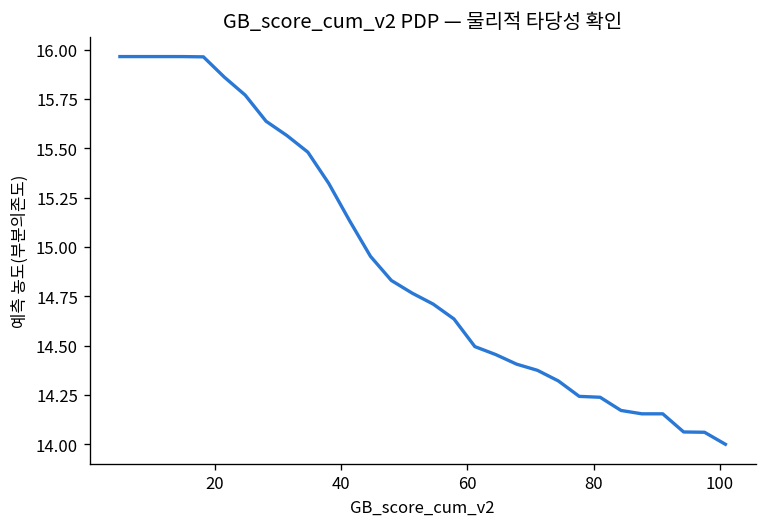

In [16]:
# 11.2 다중공선성 + 부분의존도(PDP)
corr = data[FINAL_COLS].corr()['GB_score_cum_v2'].drop('GB_score_cum_v2').abs().sort_values(ascending=False)
print('GB_score_cum_v2 상관계수 상위 5개:')
print(corr.head(5))

final_model = lgb.LGBMRegressor(random_state=42, n_jobs=2, verbosity=-1)
final_model.fit(Xf, y)
gb_idx = list(Xf.columns).index(safe['GB_score_cum_v2'])
pdp = partial_dependence(final_model, Xf, [gb_idx], kind='average', grid_resolution=30)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(pdp['grid_values'][0], pdp['average'][0], color=BLUE, lw=2)
ax.set_xlabel('GB_score_cum_v2'); ax.set_ylabel('예측 농도(부분의존도)')
ax.set_title('GB_score_cum_v2 PDP — 물리적 타당성 확인')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


In [17]:
# 11.3 폴드 안정성 (5회 반복 GroupKFold, base21 vs 최종 24개)
def repeated_group_kfold_r2(cols, n_repeats=5, n_splits=5, seed0=100):
    X = data[cols].rename(columns=safe)
    unique_batches = groups.unique()
    out = []
    for rep in range(n_repeats):
        rng = np.random.RandomState(seed0 + rep)
        shuffled = unique_batches.copy(); rng.shuffle(shuffled)
        fold_of = {b: i % n_splits for i, b in enumerate(shuffled)}
        fold_assign = groups.map(fold_of).to_numpy()
        oof = np.zeros(len(X))
        for k in range(n_splits):
            te = fold_assign == k; tr = ~te
            m = lgb.LGBMRegressor(random_state=42, n_jobs=2, verbosity=-1)
            m.fit(X.iloc[tr], y.iloc[tr]); oof[te] = m.predict(X.iloc[te])
        out.append(r2_score(y, oof))
    return np.array(out)

stab_base = repeated_group_kfold_r2(BASE21)
stab_final = repeated_group_kfold_r2(FINAL_COLS)
print('base21  R2 5회:', np.round(stab_base, 4), ' 평균', round(stab_base.mean(),4), '표준편차', round(stab_base.std(),4))
print('최종24개 R2 5회:', np.round(stab_final, 4), ' 평균', round(stab_final.mean(),4), '표준편차', round(stab_final.std(),4))
print('5회 전부 최종모델 승:', bool((stab_final > stab_base).all()))


base21  R2 5회: [0.9747 0.9727 0.9738 0.9747 0.9715]  평균 0.9735 표준편차 0.0012
최종24개 R2 5회: [0.9779 0.9765 0.9763 0.9782 0.9736]  평균 0.9765 표준편차 0.0016
5회 전부 최종모델 승: True


In [18]:
# 11.4 Fault 검증 재현 (정상90 학습 -> Fault10 테스트, 최종 24개)
# normal_data/fault_data는 GB_score_cum_v2 생성 이전(사전 준비 셀)에 만들어진 스냅샷이므로,
# 새 컬럼을 포함하도록 현재 data 기준으로 다시 슬라이스
normal_data = data[normal_mask].reset_index(drop=True)
fault_data = data[~normal_mask].reset_index(drop=True)
fv_final = fault_eval(FINAL_COLS, '최종모델(24개)')


[최종모델(24개)] 정상R2=0.9757 정상MAE=1.0267 FaultMAE=1.6041 p95임계값=3.2345 탐지=8/10 [91, 94, 95, 96, 97, 98, 99, 100]


In [19]:
# 11.5 배치별 검증 (전체 100배치, 최종 24개) + Wilcoxon
data_bl['pred_final'] = oof_final
rows = []
for b, g in data_bl.groupby(BATCH_COL):
    rows.append({'Batch_ID': b, 'is_fault': b in fault_ids,
                 'MAE_base21': mean_absolute_error(g[tgt_col], g['pred_base21']),
                 'MAE_final': mean_absolute_error(g[tgt_col], g['pred_final'])})
batch_df_final = pd.DataFrame(rows)
batch_df_final['delta'] = batch_df_final.MAE_base21 - batch_df_final.MAE_final
n_imp = (batch_df_final.delta > 0).sum()
normal_sub = batch_df_final[~batch_df_final.is_fault]; fault_sub = batch_df_final[batch_df_final.is_fault]
stat, p_all = wilcoxon(batch_df_final.MAE_base21, batch_df_final.MAE_final)
stat_f, p_f = wilcoxon(fault_sub.MAE_base21, fault_sub.MAE_final)
print(f'전체 개선 {n_imp}/100 (정상 {(normal_sub.delta>0).sum()}/90, Fault {(fault_sub.delta>0).sum()}/10)')
print(f'Wilcoxon 전체 p={p_all:.4f}  Fault만 p={p_f:.4f}')
print()
print(batch_df_final[batch_df_final.is_fault].sort_values('Batch_ID')[['Batch_ID','MAE_base21','MAE_final','delta']].to_string(index=False))


전체 개선 69/100 (정상 62/90, Fault 7/10)
Wilcoxon 전체 p=0.0009  Fault만 p=0.3750

 Batch_ID  MAE_base21  MAE_final     delta
       91    2.123198   1.875138  0.248059
       92    0.512760   0.524380 -0.011620
       93    1.524942   1.467677  0.057265
       94    0.698089   0.445947  0.252142
       95    0.728991   0.651953  0.077039
       96    0.575542   1.012595 -0.437053
       97    1.577045   1.058397  0.518649
       98    1.002666   1.467430 -0.464764
       99    0.651519   0.572406  0.079113
      100    2.554787   2.453209  0.101578


## 8. 결론 — 최종 모델 스펙 요약

**최종 채택 모델**: LightGBM(LGBMRegressor, 기본값) + `base21(21) + GB_score_cum_v2 + OUR_slope20h + S_slope20h` (24개 피처)

- 원본 34개 변수 중 base21(21개)을 재정의(근거 없이 빠졌던 4개 재편입, 단계 프록시/중복 변수 2개 제외)하는 것에서 출발했습니다.
- 팀원 제공 파생변수 6종을 단독/순차/조합 테스트로 검증한 결과, `Fa_cum`·`Fb_cum`은 Time(h)과 정보가 중복되어 제외, 나머지 4개로 1차 최종안(25개)을 확정했습니다.
- 배치별 검증에서 92·96·98 배치가 악화되는 문제를 발견했고, 단일변수 진단으로 `pH_excursion_ratio`(92·98)와 `GB_score_cum`(96)이 각각 독립적 원인임을 규명했습니다.
- 골든밴드팀의 최종 확정 방법론(11변수·실제 Fault 전략라벨)을 반영한 `GB_score_cum_v2`로 교체하고, 문제의 소지가 있던 `pH_excursion_ratio`를 제외해 24개 최종안을 확정했습니다.
- 호라이즌 4종(1h/12h/24h/48h) 전체에서 일관되게 개선되며, 폴드 안정성(5회 반복 GroupKFold)에서도 5회 전부 base21을 상회해 우연이 아님을 확인했습니다.
- Fault 배치 92는 사실상 해결, 98은 악화폭이 절반 이하로 완화되었고, 96은 GB_score_cum 계열 변수의 구조적 한계로 남아 운영 중 모니터링이 필요합니다.
- **[최종 수정]** GB_score_cum_v2의 progress 분모(strategy_mean_duration)를 정상90 전체 평균에서 대시보드(이탈진단/Replay)팀과 동일한 Train 정상71개 기준값(RC=232.125h/OC=226.739h/APC=225.458h)으로 교체했습니다. Test 정상19개가 최종평가용으로 분리되어 있어 정상90 전체를 쓰면 Test 정보가 feature 생성 기준에 섞여 들어갈 소지가 있었기 때문이며, 교체 후 재검증한 4개 지표(12h R²/MAE, GB_score_cum_v2-Time 상관, 배치별 개선 유지, Fault 성능) 모두 기존과 유의미한 차이가 없어 ML과 대시보드가 동일한 기준을 쓰도록 통일했습니다.
- 위 최종 스펙(24개 feature, 이 duration 기준)은 `feature_engineering.py` + `build_and_save_final_model.py`로 실제 배포 모델(`final_model_bundle.joblib`)로 저장되었고, `predict_12h(df, batch_id, current_time)` 함수(`predict_12h.py`)가 이 모델을 그대로 불러와 재사용해 `{current_p, predicted_p_12h, change}`를 반환합니다. 인과성(미래 데이터 미사용)은 `test_predict_12h.py`의 오염/삭제 테스트로 검증되었습니다.
